In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import sys
import pickle
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
import spk_feat_cluster_comp_analysis
importlib.reload(spk_feat_cluster_comp_analysis)
from spk_feat_cluster_comp_analysis import (
    compile_experiment_results,
    find_temporal_transitions,
    plot_temporal_transitions,
    plot_temporal_transition_legend,
    plot_temporal_transitions_highlights,
)
import config

CLUSTER_PKL_DIR = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/'

In [ ]:
df_master = compile_experiment_results(CLUSTER_PKL_DIR)

transition_save_path = os.path.join(config.SPE1_PICKLE_ROOT, 'cluster_pickles', 'temporal_transitions.pkl')
peri_save_path = os.path.join(config.SPE1_PICKLE_ROOT, 'cluster_pickles', 'lfp_peri_transition_results.pkl')

df_transitions = find_temporal_transitions(
    CLUSTER_PKL_DIR,
    r2_thresh=0.80,
    min_k=0.003,
    min_spikes=20,
    rolling_n=50,
    max_sigs=3,
    save_path=transition_save_path,
    force=False,
)

# peri_results keys are now (cell_id, feat, transition_index)
peri_results = pickle.load(open(peri_save_path, 'rb'))
used_pairs = {(k[0], k[1]) for k, v in peri_results.items() if len(v) == 3}
print(f'{len(df_transitions.groupby(["cell_id","spike_feature"]))} transitions detected, '
      f'{len(used_pairs)} cell×feature pairs used in transition point LFP analysis')

In [3]:
fig = plot_temporal_transitions(
    df_transitions,
    CLUSTER_PKL_DIR,
    df_master=df_master,
    n_cols=9,
    rolling_n=50,
    used_pairs=used_pairs,
    cells_to_exclude={
        'peak_width':      ['c15'],
        'inflection_time': ['c7'],
    },
    pairs_to_exclude_transitions={
        ('c33', 'peak_amp'),
        ('c1',  'exp_lambda'),
        ('c6',  'exp_lambda'),
        ('c31', 'exp_lambda'),
        ('c3',  'log_isi'),
    },
)
plt.show()

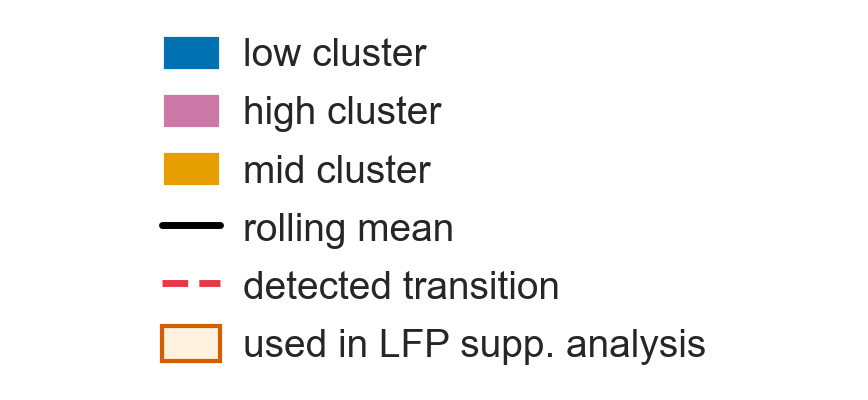

In [4]:
# Legend
fig_legend = plot_temporal_transition_legend(fontsize=14)
plt.show()

**Figure SX. Temporal trajectories of within-neuron spike feature cluster membership.**

(A) ...

(B) ...